# 010. Linear Regression

## 당뇨병 데이터를 이용한 선형회귀: 단변수 → 다변수 비교

필요한 라이브러리를 import 합니다. sklearn의 선형회귀 모델과 평가 지표를 사용합니다.

In [1]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
from sklearn import datasets, linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

### diabetes dataset
- 나이, 성별, 체질량지수, 혈압, 6가지 혈청 수치를 이용하여 1년 후의 당뇨병 진행률을 예측
- 10개의 Feature는 이미 정규화(scaling)되어 있음

In [2]:
# 당뇨병 데이터셋 로드 (이미 정규화된 데이터)
diabetes = datasets.load_diabetes()
print(f"Feature 이름: {diabetes.feature_names}")
print(f"데이터 크기: {diabetes.data.shape} (샘플 수, 특성 수)")

Feature 이름: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
데이터 크기: (442, 10) (샘플 수, 특성 수)


In [3]:
# DataFrame으로 변환
df_diab = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df_diab['target'] = diabetes.target
df_diab.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


---
## Part 1. Univariate Linear Regression (단변수 선형회귀)

BMI(체질량지수) 하나의 특성만 사용하여 당뇨병 진행률을 예측합니다.

### 데이터 분할

`train_test_split`을 사용하여 훈련/테스트 데이터를 분할합니다.  
셔플 후 분할하므로 데이터 순서에 의한 편향을 방지할 수 있습니다.

In [4]:
# 단변수: BMI만 사용
X_bmi = df_diab[['bmi']].values
y = diabetes.target

# train_test_split으로 분할 (80:20, 셔플 포함)
X_train, X_test, y_train, y_test = train_test_split(
    X_bmi, y, test_size=0.2, random_state=42
)
print(f"훈련 세트: {X_train.shape[0]}개, 테스트 세트: {X_test.shape[0]}개")

훈련 세트: 353개, 테스트 세트: 89개


### 모델 학습 및 예측

In [5]:
# 선형회귀 모델 생성 및 학습
regr_uni = linear_model.LinearRegression()
regr_uni.fit(X_train, y_train)

# 테스트 데이터 예측
y_pred_uni = regr_uni.predict(X_test)

# 회귀식 확인: y = coef * x + intercept
print(f"회귀 계수(기울기): {regr_uni.coef_[0]:.2f}")
print(f"절편: {regr_uni.intercept_:.2f}")

회귀 계수(기울기): 998.58
절편: 152.00


### 회귀식을 이용한 수동 예측 vs predict 비교

In [10]:
# 수동 예측
y_manual = regr_uni.coef_[0] * X_sample + regr_uni.intercept_
# predict method 사용
y_predict = regr_uni.predict(np.array([[X_sample]]))[0]

print(f"수동 계산: {y_manual:.2f}")
print(f"predict():  {y_predict:.2f}")

수동 계산: 176.97
predict():  176.97


### BMI vs 진행률 시각화

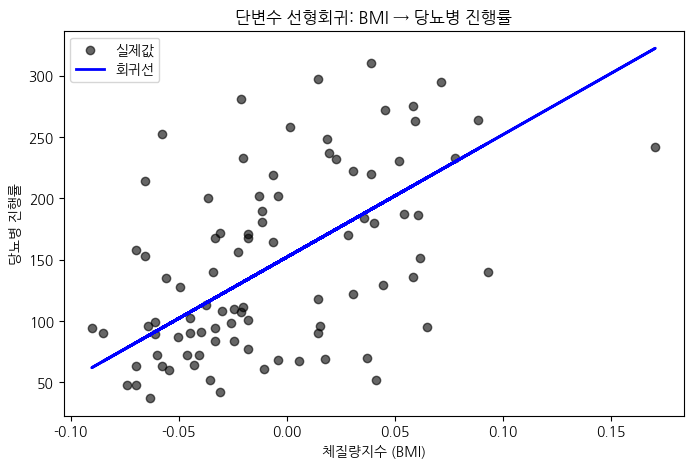

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='black', alpha=0.6, label='실제값')
plt.plot(X_test, y_pred_uni, color='blue', linewidth=2, label='회귀선')
plt.xlabel('체질량지수 (BMI)')
plt.ylabel('당뇨병 진행률')
plt.title('단변수 선형회귀: BMI → 당뇨병 진행률')
plt.legend()
plt.show()

### 평가: R² Score & RMSE

**MSE → RMSE 관계:**

$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
\qquad\Longrightarrow\qquad
\mathrm{RMSE} = \sqrt{\mathrm{MSE}}
$$

- **R²**: 1에 가까울수록 좋음 (모델이 분산을 얼마나 설명하는지)
- **RMSE**: 0에 가까울수록 좋음 (예측 오차의 크기, 타겟과 같은 단위)

In [12]:
r2_uni = r2_score(y_test, y_pred_uni)
mse_uni = mean_squared_error(y_test, y_pred_uni)
rmse_uni = np.sqrt(mse_uni)

print(f"[단변수 선형회귀 - BMI only]")
print(f"  R² Score: {r2_uni:.4f}")
print(f"  MSE:      {mse_uni:.2f}")
print(f"  RMSE:     {rmse_uni:.2f}")
print(f"  → 예측값이 평균적으로 실제값과 약 {rmse_uni:.1f} 정도 차이남")

[단변수 선형회귀 - BMI only]
  R² Score: 0.2334
  MSE:      4061.83
  RMSE:     63.73
  → 예측값이 평균적으로 실제값과 약 63.7 정도 차이남


---
## Part 2. Multivariate Linear Regression (다변수 선형회귀)

10개의 전체 특성을 사용하여 예측 성능을 향상시킵니다.

In [13]:
# 다변수: 전체 Feature 사용
X_all = diabetes.data  # 10개 특성 전체

# 동일한 조건으로 분할 (같은 random_state)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# 모델 학습 및 예측
regr_multi = linear_model.LinearRegression()
regr_multi.fit(X_train_m, y_train_m)
y_pred_multi = regr_multi.predict(X_test_m)

In [14]:
r2_multi = r2_score(y_test_m, y_pred_multi)
mse_multi = mean_squared_error(y_test_m, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)

print(f"[다변수 선형회귀 - 10개 Feature]")
print(f"  R² Score: {r2_multi:.4f}")
print(f"  MSE:      {mse_multi:.2f}")
print(f"  RMSE:     {rmse_multi:.2f}")

[다변수 선형회귀 - 10개 Feature]
  R² Score: 0.4526
  MSE:      2900.19
  RMSE:     53.85


### 다변수 회귀: 실제값 vs 예측값 시각화

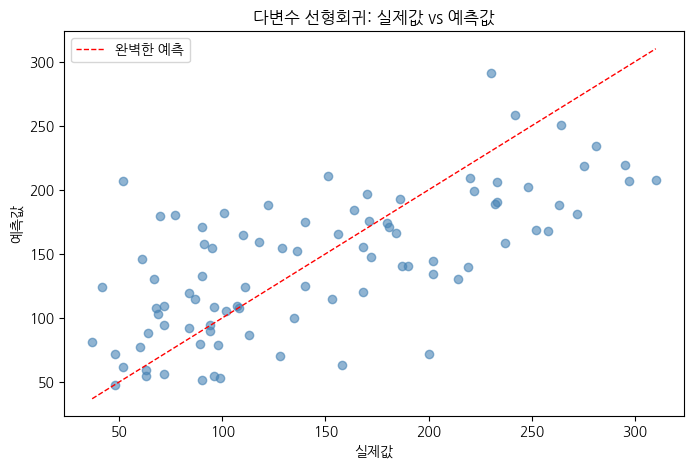

In [15]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test_m, y_pred_multi, color='steelblue', alpha=0.6)
# 대각선 (완벽한 예측 기준선)
min_val = min(y_test_m.min(), y_pred_multi.min())
max_val = max(y_test_m.max(), y_pred_multi.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1, label='완벽한 예측')
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title('다변수 선형회귀: 실제값 vs 예측값')
plt.legend()
plt.show()

---
## 단변수 vs 다변수 성능 비교

In [16]:
# 비교 요약 테이블
comparison = pd.DataFrame({
    '모델': ['단변수 (BMI only)', '다변수 (10 Features)'],
    'R² Score': [r2_uni, r2_multi],
    'MSE': [mse_uni, mse_multi],
    'RMSE': [rmse_uni, rmse_multi]
}).set_index('모델')

print(comparison.round(4).to_string())
print(f"\n✅ 다변수 회귀가 R²는 {r2_multi - r2_uni:.4f} 향상, RMSE는 {rmse_uni - rmse_multi:.2f} 감소")

                   R² Score        MSE     RMSE
모델                                             
단변수 (BMI only)       0.2334  4061.8259  63.7325
다변수 (10 Features)    0.4526  2900.1936  53.8534

✅ 다변수 회귀가 R²는 0.2193 향상, RMSE는 9.88 감소
